<div style="
    width:100%;
    box-sizing:border-box;
    margin:10px 0 35px 0;
    padding:45px 50px;
    background:linear-gradient(135deg,#FFFDF8 0%,#F3EBDD 100%);
    border:1px solid #D8CCBA;
    border-left:8px solid #315C47;
    border-radius:26px;
    box-shadow:0 10px 28px rgba(49,92,71,0.10);
">

<h1 style="
    margin:0;
    color:#315C47;
    font-size:38px;
    font-weight:800;
">
🖼️ Day 3 — Computer Vision Preprocessing with OpenCV
</h1>

<p style="
    margin:14px 0 0 0;
    color:#6F6253;
    font-size:19px;
">
Image Preprocessing • OpenCV • Augmentation • Transfer Learning
</p>

<div style="
    margin-top:25px;
    padding:18px 22px;
    background:#FFFFFF;
    border-radius:16px;
    border:1px solid #E1D7C8;
    color:#4E463D;
    font-size:16px;
    line-height:1.7;
">

<strong style="color:#315C47;">🎯 Today's Focus</strong><br>

Learn how to transform raw images into consistent,
model-ready inputs using OpenCV and TensorFlow/Keras.

</div>

</div>

In [3]:
%pip install opencv-python

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
    --------------------------------------- 0.8/44.0 MB 2.8 MB/s eta 0:00:16
   --- ------------------------------------ 3.4/44.0 MB 7.5 MB/s eta 0:00:06
   ---- ----------------------------------- 5.0/44.0 MB 7.7 MB/s eta 0:00:06
   ------- -------------------------------- 7.9/44.0 MB 9.4 MB/s eta 0:00:04
   --------- ------------------------------ 10.5/44.0 MB 9.9 MB/s eta 0:00:04
   ----------- ---------------------------- 12.6/44.0 MB 10.0 MB/s eta 0:00:04
   -------------- ------------------------- 15.5/44.0 MB 10.4 MB/s eta 0:00:03
   ---------------- ----------------------- 18.1/44.0 MB 10.7 MB/s eta 0:00:03
   ------------------ --------------------- 19.9/44.0 MB 10.5 MB/s eta 0:00:03
   -------------------- ------------------- 22.5/44.0 MB 10.7 MB/s eta 0:00:03
   ----------------------- ---------------- 25.4/44.0 MB 11.0 MB/s eta 0:00:02


In [19]:
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np


print("OpenCV version:", cv2.__version__)
print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

print("\n✅ All required libraries imported successfully!")

OpenCV version: 5.0.0
TensorFlow version: 2.21.0
NumPy version: 2.5.2

✅ All required libraries imported successfully!


<div style="
    width:100%;
    box-sizing:border-box;
    margin:35px 0 25px 0;
    padding:30px 35px;
    background:linear-gradient(135deg,#315C47 0%,#264A39 100%);
    border-radius:22px;
    box-shadow:0 9px 22px rgba(49,92,71,0.18);
">

<h2 style="
    margin:0;
    color:#FFFDF8;
    font-size:30px;
">
🖼️ 3.1 Why Images Need Preprocessing
</h2>

<p style="
    margin:10px 0 0 0;
    color:#EDE4D6;
    font-size:16px;
">
Understanding why raw images need to be standardized before training.
</p>

</div>

<div style="
    width:100%;
    box-sizing:border-box;
    padding:30px 34px;
    background:#FFFDF8;
    border:1px solid #D8CCBA;
    border-radius:20px;
    box-shadow:0 6px 18px rgba(49,92,71,0.06);
">

<h3 style="
    margin:0 0 18px 0;
    color:#315C47;
    font-size:25px;
">
🔍 Why Do Images Need Preprocessing?
</h3>

<p style="
    color:#4E463D;
    font-size:17px;
    line-height:1.9;
">
Images collected from different sources may have different
<strong>sizes, color formats, pixel ranges, and visual characteristics.</strong>
</p>

<p style="
    color:#4E463D;
    font-size:17px;
    line-height:1.9;
">
A neural network works better when the input data follows a
consistent format. Image preprocessing converts raw images into
a standardized representation that can be efficiently consumed
by the model.
</p>

<div style="
    margin-top:22px;
    padding:18px 20px;
    background:#F3EBDD;
    border-radius:14px;
    color:#4E463D;
    font-size:16px;
    line-height:1.7;
">

<strong style="color:#315C47;">📌 Common preprocessing tasks:</strong>

<br>• Resize images to a fixed size
<br>• Convert color channels when necessary
<br>• Normalize pixel values
<br>• Remove unwanted variations
<br>• Prepare inputs according to model requirements

</div>

</div>

<div style="
    width:100%;
    box-sizing:border-box;
    margin:35px 0 25px 0;
    padding:30px 35px;
    background:linear-gradient(135deg,#315C47 0%,#264A39 100%);
    border-radius:22px;
">

<h2 style="
    margin:0;
    color:#FFFDF8;
    font-size:30px;
">
🔧 3.2 OpenCV Fundamentals
</h2>

<p style="
    margin:10px 0 0 0;
    color:#EDE4D6;
    font-size:16px;
">
Using OpenCV for basic image preprocessing operations.
</p>

</div>

<div style="
    width:100%;
    box-sizing:border-box;
    padding:28px 30px;
    background:#FFFDF8;
    border:1px solid #D8CCBA;
    border-radius:20px;
">

<h3 style="
    margin:0 0 20px 0;
    color:#315C47;
    font-size:24px;
">
🧩 Core OpenCV Operations
</h3>

<table style="
    width:100%;
    border-collapse:collapse;
    color:#4E463D;
    font-size:16px;
">

<tr style="background:#315C47;color:white;">
<th style="padding:14px;text-align:left;">Operation</th>
<th style="padding:14px;text-align:left;">Function</th>
<th style="padding:14px;text-align:left;">Purpose</th>
</tr>

<tr style="background:#F8F3EA;">
<td style="padding:14px;"><strong>📂 Read</strong></td>
<td style="padding:14px;"><code>cv2.imread()</code></td>
<td style="padding:14px;">Load an image from disk.</td>
</tr>

<tr>
<td style="padding:14px;"><strong>📐 Resize</strong></td>
<td style="padding:14px;"><code>cv2.resize()</code></td>
<td style="padding:14px;">Change the image dimensions.</td>
</tr>

<tr style="background:#F8F3EA;">
<td style="padding:14px;"><strong>🎨 Color Conversion</strong></td>
<td style="padding:14px;"><code>cv2.cvtColor()</code></td>
<td style="padding:14px;">Convert between color spaces.</td>
</tr>

<tr>
<td style="padding:14px;"><strong>📊 Normalization</strong></td>
<td style="padding:14px;"><code>/ 255.0</code></td>
<td style="padding:14px;">Scale pixels from 0–255 to 0–1.</td>
</tr>

<tr style="background:#F8F3EA;">
<td style="padding:14px;"><strong>🖊️ Edge Detection</strong></td>
<td style="padding:14px;"><code>cv2.Canny()</code></td>
<td style="padding:14px;">Detect image edges.</td>
</tr>

</table>

</div>

<div style="
    padding:22px 28px;
    background:#FFFDF8;
    border:1px solid #D8CCBA;
    border-left:6px solid #315C47;
    border-radius:17px;
">

<h3 style="margin:0;color:#315C47;font-size:23px;">
📂 Step 1 — Read the Image
</h3>

<p style="
    color:#4E463D;
    font-size:16px;
    line-height:1.8;
">
OpenCV provides <code>cv2.imread()</code> to load an image into
memory as a NumPy array.
</p>

</div>

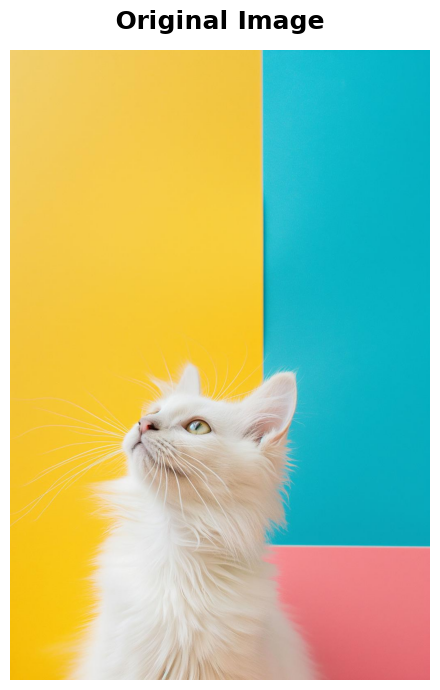

In [33]:
plt.figure(figsize=(7, 7))

plt.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
plt.title(
    "Original Image",
    fontsize=18,
    fontweight="bold",
    pad=15
)
plt.axis("off")

plt.tight_layout()
plt.show()

<div style="
    padding:22px 28px;
    background:#FFFDF8;
    border:1px solid #D8CCBA;
    border-left:6px solid #B88A44;
    border-radius:17px;
">

<h3 style="margin:0;color:#315C47;font-size:23px;">
📐 Step 2 — Resize the Image
</h3>

<p style="
    color:#4E463D;
    font-size:16px;
    line-height:1.8;
">
Deep learning models usually expect every image to have the same
height and width. We therefore resize the image to a fixed size.
</p>

</div>

In [34]:
target_size = (224, 224)

resized_bgr = cv2.resize(
    image_bgr,
    target_size,
    interpolation=cv2.INTER_AREA
)

print("Original shape:", image_bgr.shape)
print("Resized shape:", resized_bgr.shape)

Original shape: (1536, 1024, 3)
Resized shape: (224, 224, 3)


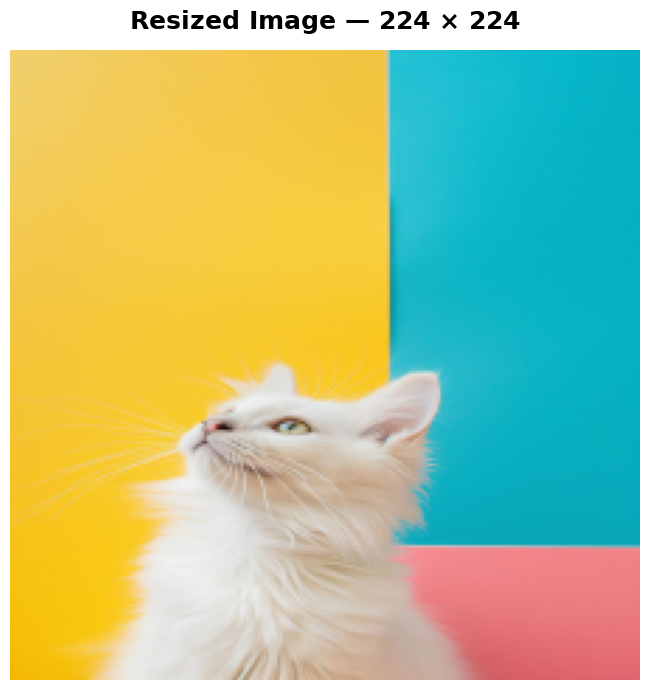

In [35]:
plt.figure(figsize=(7, 7))

plt.imshow(cv2.cvtColor(resized_bgr, cv2.COLOR_BGR2RGB))
plt.title(
    "Resized Image — 224 × 224",
    fontsize=18,
    fontweight="bold",
    pad=15
)
plt.axis("off")

plt.tight_layout()
plt.show()

<div style="
    padding:22px 28px;
    background:#FFFDF8;
    border:1px solid #D8CCBA;
    border-left:6px solid #315C47;
    border-radius:17px;
">

<h3 style="margin:0;color:#315C47;font-size:23px;">
🎨 Step 3 — Convert BGR to RGB
</h3>

<p style="
    color:#4E463D;
    font-size:16px;
    line-height:1.8;
">
OpenCV stores color images using the
<strong>BGR</strong> channel order.
Matplotlib and most deep learning workflows commonly use
<strong>RGB</strong>.
</p>

</div>

In [40]:
image_rgb = cv2.cvtColor(
    resized_bgr,
    cv2.COLOR_BGR2RGB
)

print("Color conversion completed.")
print("RGB image shape:", image_rgb.shape)

Color conversion completed.
RGB image shape: (224, 224, 3)


<div style="
    padding:22px 28px;
    background:#FFFDF8;
    border:1px solid #D8CCBA;
    border-left:6px solid #315C47;
    border-radius:17px;
">

<h3 style="margin:0;color:#315C47;font-size:23px;">
📊 Step 4 — Normalize Pixel Values
</h3>

<p style="
    color:#4E463D;
    font-size:16px;
    line-height:1.8;
">
A standard image normally contains pixel values between
<strong>0 and 255</strong>.
Dividing by 255 scales these values to the range
<strong>0–1</strong>.
</p>

</div>

In [23]:
normalized_image = image_rgb.astype(np.float32) / 255.0

print("Minimum pixel value:", normalized_image.min())
print("Maximum pixel value:", normalized_image.max())
print("Data type:", normalized_image.dtype)

Minimum pixel value: 0.0
Maximum pixel value: 1.0
Data type: float32


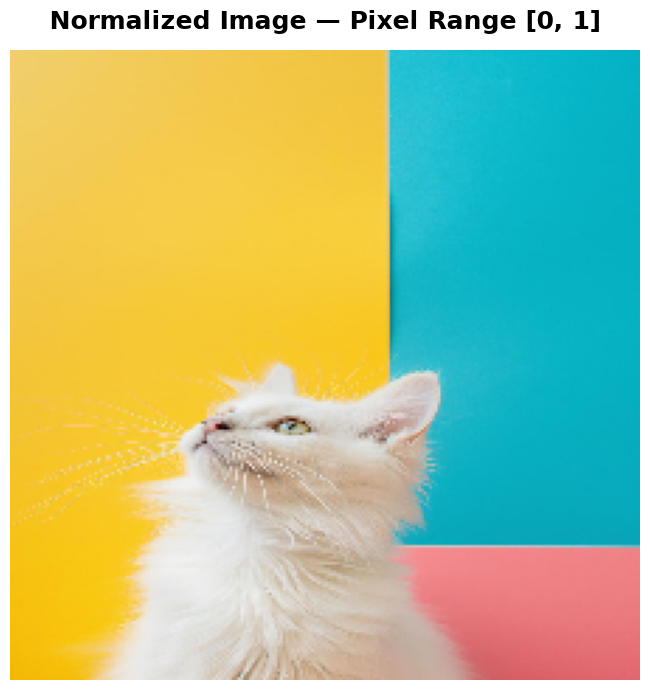

In [24]:
plt.figure(figsize=(7, 7))

plt.imshow(normalized_image)
plt.title(
    "Normalized Image — Pixel Range [0, 1]",
    fontsize=18,
    fontweight="bold",
    pad=15
)
plt.axis("off")

plt.tight_layout()
plt.show()

<div style="
    width:100%;
    box-sizing:border-box;
    padding:27px 32px;
    background:linear-gradient(135deg,#FFF8EA 0%,#F7EEDC 100%);
    border:1px solid #D8C39B;
    border-left:7px solid #B88A44;
    border-radius:19px;
">

<h3 style="
    margin:0 0 14px 0;
    color:#8A6530;
    font-size:24px;
">
⚠️ BGR vs RGB — A Common Pitfall
</h3>

<p style="
    margin:0;
    color:#5A4D3D;
    font-size:17px;
    line-height:1.8;
">
OpenCV reads images as <strong>BGR</strong>, not RGB.
If we display an OpenCV image directly with Matplotlib,
the red and blue channels can be swapped and the image may
appear with incorrect colors.
</p>

<div style="
    margin-top:20px;
    padding:17px 20px;
    background:#FFFDF8;
    border-radius:14px;
">

<strong style="color:#315C47;">Correct conversion:</strong>

<br><br>

<code style="font-size:16px;color:#315C47;">
cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
</code>

</div>

</div>

<div style="
    width:100%;
    box-sizing:border-box;
    margin:38px 0 25px 0;
    padding:30px 35px;
    background:linear-gradient(135deg,#315C47 0%,#264A39 100%);
    border-radius:22px;
">

<h2 style="
    margin:0;
    color:#FFFDF8;
    font-size:30px;
">
🔄 3.3 Building an Augmentation Pipeline
</h2>

<p style="
    margin:10px 0 0 0;
    color:#EDE4D6;
    font-size:16px;
">
Generating realistic image variations to improve model generalization.
</p>

</div>

<div style="
    padding:27px 32px;
    background:#FFFDF8;
    border:1px solid #D8CCBA;
    border-radius:19px;
">

<h3 style="
    margin:0 0 14px 0;
    color:#315C47;
    font-size:24px;
">
🧠 What Is Image Augmentation?
</h3>

<p style="
    color:#4E463D;
    font-size:17px;
    line-height:1.8;
">
Image augmentation creates different versions of an existing image
by applying transformations such as rotation, zoom, flipping,
and brightness changes.
</p>

<p style="
    color:#4E463D;
    font-size:17px;
    line-height:1.8;
">
These variations expose the model to more diverse examples and
can help it generalize better to unseen images.
</p>

</div>

<div style="
    padding:22px 28px;
    background:#FFFDF8;
    border:1px solid #D8CCBA;
    border-left:6px solid #315C47;
    border-radius:17px;
">

<h3 style="margin:0;color:#315C47;font-size:23px;">
🧰 Creating the Augmentation Pipeline
</h3>

<p style="
    color:#4E463D;
    font-size:16px;
    line-height:1.8;
">
We will use Keras
<strong>ImageDataGenerator</strong>
to apply several transformations during image generation.
</p>

</div>

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

augmentation_generator = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.20,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),
    rescale=1.0 / 255.0
)

print("✅ Augmentation pipeline created successfully!")

✅ Augmentation pipeline created successfully!


<div style="
    padding:24px 30px;
    background:#F3EBDD;
    border-radius:17px;
    color:#4E463D;
    font-size:16px;
    line-height:1.8;
">

<strong style="color:#315C47;">🔎 What does each parameter do?</strong>

<br><br>

<strong>rotation_range=20</strong>
→ Randomly rotates the image up to 20 degrees.

<br>

<strong>zoom_range=0.20</strong>
→ Randomly zooms into or out of the image.

<br>

<strong>horizontal_flip=True</strong>
→ Randomly flips the image horizontally.

<br>

<strong>brightness_range=(0.8, 1.2)</strong>
→ Randomly changes image brightness.

<br>

<strong>rescale=1/255</strong>
→ Converts pixel values from 0–255 to approximately 0–1.

</div>

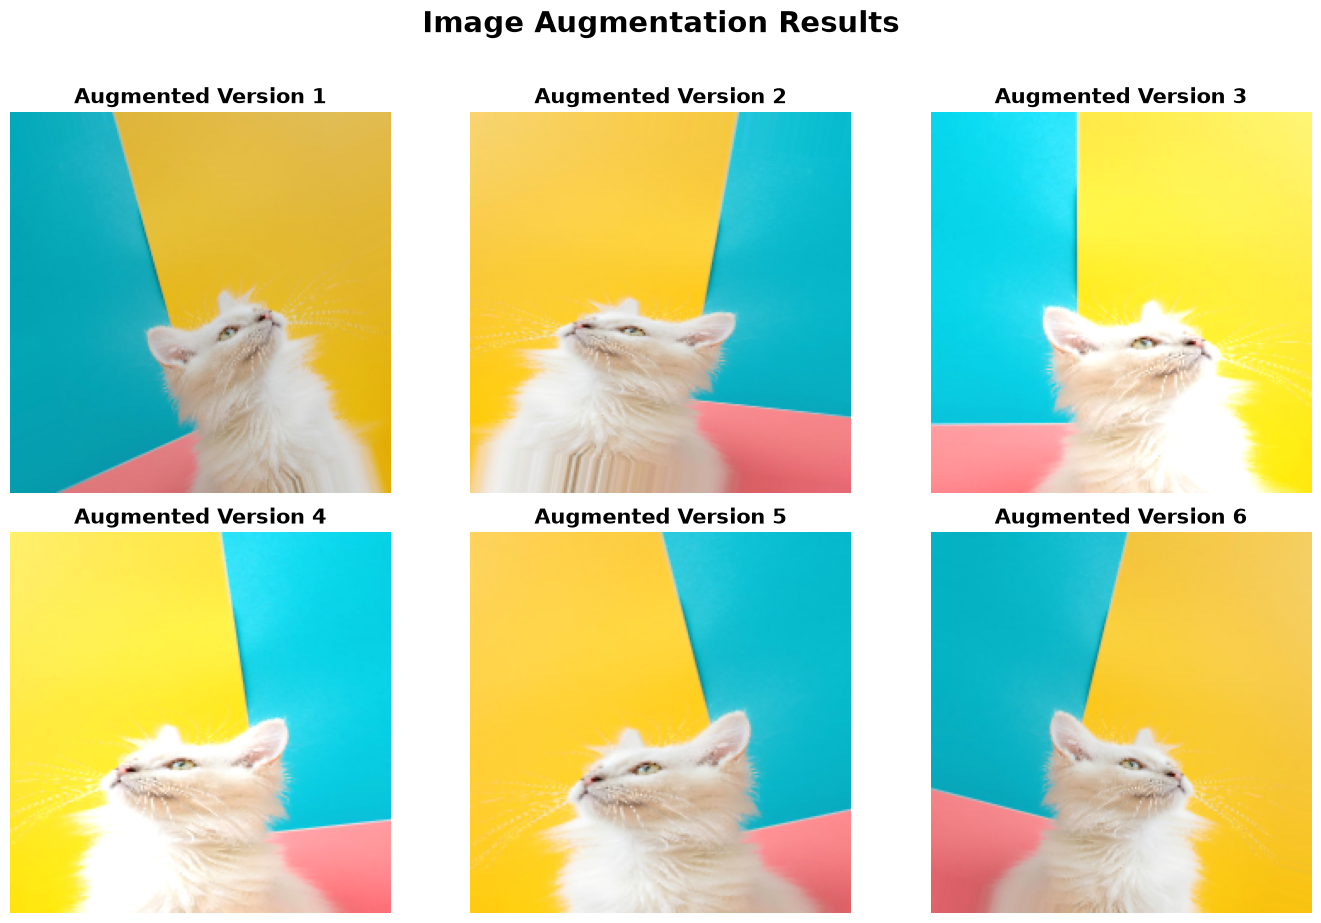

In [26]:
plt.figure(figsize=(14, 9))

for i in range(6):
    augmented_image = next(augmented_images)[0]

    plt.subplot(2, 3, i + 1)
    plt.imshow(augmented_image)
    plt.title(
        f"Augmented Version {i + 1}",
        fontsize=15,
        fontweight="bold"
    )
    plt.axis("off")

plt.suptitle(
    "Image Augmentation Results",
    fontsize=21,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

<div style="
    padding:24px 30px;
    background:#FFFDF8;
    border:1px solid #D8CCBA;
    border-radius:18px;
">

<h3 style="
    margin:0 0 12px 0;
    color:#315C47;
    font-size:23px;
">
👀 What Should We Observe?
</h3>

<p style="
    margin:0;
    color:#4E463D;
    font-size:17px;
    line-height:1.8;
">
Although all generated images come from the same original image,
each version can have a different rotation, zoom level,
horizontal orientation, or brightness.
</p>

<p style="
    margin:14px 0 0 0;
    color:#4E463D;
    font-size:17px;
    line-height:1.8;
">
This gives the model more visual variation during training without
requiring us to manually collect additional images.
</p>

</div>

<div style="
    width:100%;
    box-sizing:border-box;
    margin:38px 0 25px 0;
    padding:30px 35px;
    background:linear-gradient(135deg,#315C47 0%,#264A39 100%);
    border-radius:22px;
">

<h2 style="
    margin:0;
    color:#FFFDF8;
    font-size:30px;
">
🔗 3.4 Connecting to Transfer Learning
</h2>

<p style="
    margin:10px 0 0 0;
    color:#EDE4D6;
    font-size:16px;
">
Matching our preprocessing pipeline to a pre-trained model.
</p>

</div>

<div style="
    padding:28px 32px;
    background:#FFFDF8;
    border:1px solid #D8CCBA;
    border-left:6px solid #315C47;
    border-radius:19px;
">

<h3 style="
    margin:0 0 15px 0;
    color:#315C47;
    font-size:24px;
">
🧠 Why Does Transfer Learning Need Specific Preprocessing?
</h3>

<p style="
    color:#4E463D;
    font-size:17px;
    line-height:1.8;
">
A pre-trained model was trained using a specific preprocessing
strategy. Therefore, when we use that model on our own images,
we should prepare the images in a compatible way.
</p>

<p style="
    color:#4E463D;
    font-size:17px;
    line-height:1.8;
">
For example, some models expect pixel values scaled to
<strong>[0, 1]</strong>, while others use preprocessing functions
that normalize values differently.
</p>

<div style="
    margin-top:20px;
    padding:18px 20px;
    background:#F3EBDD;
    color:#315C47;
    border-radius:14px;
">

<strong style="color:#315C47;">📌 Important:</strong>

<br >

Always check the preprocessing requirements of the specific
pre-trained architecture you are using.

</div>

</div>

In [27]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Example image prepared for MobileNetV2
model_input = preprocess_input(
    image_rgb.astype(np.float32) * 255.0
)

print("Preprocessed shape:", model_input.shape)
print("Minimum value:", model_input.min())
print("Maximum value:", model_input.max())

Preprocessed shape: (224, 224, 3)
Minimum value: -1.0
Maximum value: 509.0


<div style="
    padding:25px 30px;
    background:#FFFDF8;
    border:1px solid #D8CCBA;
    border-radius:18px;
">

<h3 style="
    margin:0 0 12px 0;
    color:#315C47;
    font-size:23px;
">
💡 Key Takeaway
</h3>

<p style="
    margin:0;
    color:#4E463D;
    font-size:17px;
    line-height:1.8;
">
The important lesson is not that every model uses the same
preprocessing. The important lesson is that
<strong>the preprocessing used for our input must match the
expectations of the selected pre-trained model.</strong>
</p>

</div>

<div style="
    width:100%;
    box-sizing:border-box;
    margin:40px 0 25px 0;
    padding:32px 36px;
    background:linear-gradient(135deg,#B88A44 0%,#9A7137 100%);
    border-radius:22px;
    box-shadow:0 9px 22px rgba(184,138,68,0.18);
">

<h2 style="
    margin:0;
    color:#FFFDF8;
    font-size:30px;
">
🧪 Hands-On Lab — Image Preprocessing + Mentor Review
</h2>

<p style="
    margin:10px 0 0 0;
    color:#FFF4DF;
    font-size:16px;
">
Integrate all preprocessing concepts into one reusable workflow.
</p>

</div>

<div style="
    padding:24px 28px;
    background:#FFFDF8;
    border:1px solid #D8CCBA;
    border-left:7px solid #315C47;
    border-radius:18px;
">

<h3 style="margin:0;color:#315C47;font-size:23px;">
🟢 Step 1 — Build an OpenCV Preprocessing Function
</h3>

<p style="
    color:#4E463D;
    font-size:16px;
    line-height:1.8;
">
Create a reusable function that performs the complete basic
preprocessing pipeline:
</p>

<ul style="
    color:#4E463D;
    font-size:16px;
    line-height:1.8;
">

<li>Read the image</li>
<li>Resize it to a fixed size</li>
<li>Convert BGR → RGB</li>
<li>Normalize pixel values</li>

</ul>

</div>

In [28]:
def preprocess_image(image_path, target_size=(224, 224)):
    """
    Read, resize, convert BGR to RGB,
    and normalize an image.
    """

    image = cv2.imread(image_path)

    if image is None:
        raise FileNotFoundError(
            f"Could not read image: {image_path}"
        )

    image = cv2.resize(image, target_size)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    image = image.astype(np.float32) / 255.0

    return image


processed_image = preprocess_image(
    "sample_image.jpg"
)

print("Processed image shape:", processed_image.shape)
print("Pixel range:",
      processed_image.min(),
      "to",
      processed_image.max())

Processed image shape: (224, 224, 3)
Pixel range: 0.0 to 1.0


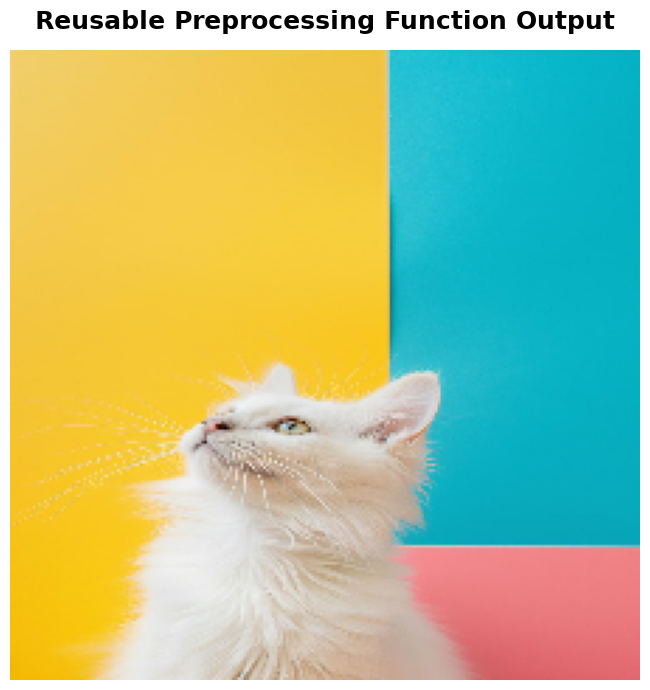

In [29]:
plt.figure(figsize=(7, 7))

plt.imshow(processed_image)
plt.title(
    "Reusable Preprocessing Function Output",
    fontsize=18,
    fontweight="bold",
    pad=15
)
plt.axis("off")

plt.tight_layout()
plt.show()

<div style="
    padding:24px 28px;
    background:#FFFDF8;
    border:1px solid #D8CCBA;
    border-left:7px solid #315C47;
    border-radius:18px;
">

<h3 style="margin:0;color:#315C47;font-size:23px;">
🟢 Step 2 — Create and Visualize Augmentations
</h3>

<p style="
    color:#4E463D;
    font-size:16px;
    line-height:1.8;
">
Use the augmentation pipeline to generate several different
versions of the same image and visualize the results.
</p>

</div>

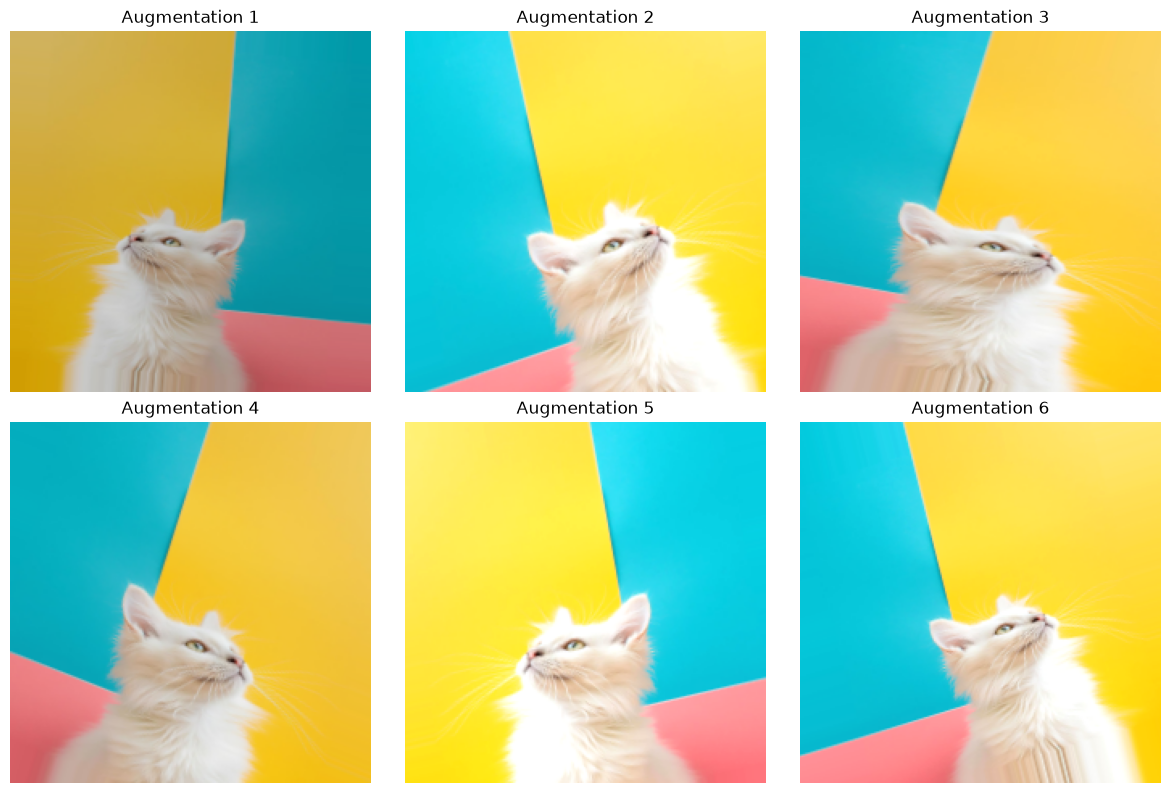

In [30]:
augmentation_generator = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.20,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),
    rescale=1.0 / 255.0
)

original_image = cv2.imread("sample_image.jpg")

if original_image is None:
    raise FileNotFoundError("Image not found.")

# original_image = cv2.resize(
#     original_image,
#     (224, 224)
# )

original_image = cv2.resize(
    original_image,
    (224, 224),
    interpolation=cv2.INTER_AREA
)

original_image = cv2.cvtColor(
    original_image,
    cv2.COLOR_BGR2RGB
)

batch = np.expand_dims(
    original_image,
    axis=0
)

generator = augmentation_generator.flow(
    batch,
    batch_size=1,
    shuffle=False,
    seed=42
)

plt.figure(figsize=(12, 8))

for i in range(6):
    augmented = next(generator)[0]

    plt.subplot(2, 3, i + 1)
    plt.imshow(augmented)
    plt.title(f"Augmentation {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

<div style="
    padding:24px 28px;
    background:#FFFDF8;
    border:1px solid #D8CCBA;
    border-left:7px solid #315C47;
    border-radius:18px;
">

<h3 style="margin:0;color:#315C47;font-size:23px;">
🟢 Step 3 — Connect Preprocessing to Transfer Learning
</h3>

<p style="
    color:#4E463D;
    font-size:16px;
    line-height:1.8;
">
If the project uses an image-based pre-trained model,
apply the preprocessing function required by that architecture.
</p>

<p style="
    color:#4E463D;
    font-size:16px;
    line-height:1.8;
">
For this example, we will demonstrate the preprocessing expected
by <strong>MobileNetV2</strong>.
</p>

</div>

In [31]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

image_for_transfer = original_image.astype(np.float32)

transfer_ready_image = preprocess_input(
    image_for_transfer
)

transfer_ready_batch = np.expand_dims(
    transfer_ready_image,
    axis=0
)

print("Model-ready shape:", transfer_ready_batch.shape)
print("Minimum value:", transfer_ready_batch.min())
print("Maximum value:", transfer_ready_batch.max())

Model-ready shape: (1, 224, 224, 3)
Minimum value: -0.99215686
Maximum value: 0.9843137


<div style="
    padding:26px 30px;
    background:linear-gradient(135deg,#FFFDF8 0%,#F3EBDD 100%);
    border:1px solid #D8CCBA;
    border-left:7px solid #B88A44;
    border-radius:19px;
">

<h3 style="
    margin:0 0 15px 0;
    color:#8A6530;
    font-size:24px;
">
🟢 Step 4 — Mentor Code & Notebook Review
</h3>

<p style="
    color:#4E463D;
    font-size:17px;
    line-height:1.8;
">
After completing the integrated notebook, push the changes to
GitHub and open a Pull Request for the mid-sprint mentor review.
</p>

<div style="
    margin-top:18px;
    padding:18px 20px;
    background:#FFFDF8;
    color:#315C47;
    border-radius:14px;
">

<strong style="color:#315C47;">📋 Review Checklist</strong>

<br><br>

☐ Notebook runs without errors

<br>
☐ Image preprocessing function works correctly

<br>
☐ BGR → RGB conversion is handled correctly

<br>
☐ Pixel normalization is applied correctly

<br>
☐ Augmentation pipeline works

<br>
☐ Augmented images are visualized

<br>
☐ Transfer-learning preprocessing matches the selected model

<br>
☐ README is completed

</div>

</div>

<div style="
    width:100%;
    box-sizing:border-box;
    margin:35px 0 40px 0;
    padding:32px 35px;
    background:linear-gradient(135deg,#FFFDF8 0%,#F3EBDD 100%);
    border:1px solid #D8CCBA;
    border-radius:22px;
    box-shadow:0 8px 22px rgba(49,92,71,0.08);
">

<h2 style="
    margin:0 0 22px 0;
    color:#315C47;
    font-size:29px;
">
✅ Day 3 — Completion Checklist
</h2>

<div style="
    color:#4E463D;
    font-size:17px;
    line-height:2;
">

☑️ VS Code opened and <code>.venv</code> activated

<br>
☑️ <code>Day3</code> folder created

<br>
☑️ <code>opencv_preprocessing.ipynb</code> created

<br>
☑️ <code>README.md</code> created

<br>
☑️ <code>opencv-python</code> verified

<br>
☑️ <code>tensorflow</code> verified

<br>
☑️ <code>matplotlib</code> verified

<br>
☑️ Explained why images need preprocessing

<br>
☑️ Read image using OpenCV

<br>
☑️ Resized image

<br>
☑️ Converted BGR → RGB

<br>
☑️ Normalized pixel values

<br>
☑️ Explained BGR vs RGB

<br>
☑️ Created ImageDataGenerator

<br>
☑️ Applied rotation

<br>
☑️ Applied zoom

<br>
☑️ Applied horizontal flip

<br>
☑️ Applied brightness shift

<br>
☑️ Applied rescaling

<br>
☑️ Visualized augmented images

<br>
☑️ Explained transfer-learning preprocessing

<br>
☑️ Demonstrated <code>preprocess_input</code>

<br>
☑️ Built reusable preprocessing function

<br>
☑️ Completed Hands-On Lab

<br>
☑️ Filled README

<br>
☑️ Saved notebook

<br>
☑️ Committed changes

<br>
☑️ Pushed to GitHub

<br>
☑️ Opened Pull Request

<br>
☑️ Submitted for Mentor Review

</div>

<div style="
    margin-top:25px;
    padding:20px;
    background:#315C47;
    border-radius:15px;
    text-align:center;
    color:#FFFDF8;
    font-size:19px;
    font-weight:700;
">
🎉 Day 3 Complete — Images Are Now Model-Ready!
</div>

</div>